## Cohort Clustering


This notebook creates customer cohorts using engineered customer-level features.

**Goal**: segment customers into interpretable business cohorts for lead generation and sales prioritization.

Setup

In [8]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

INPUT_DIR = Path("../data/feature_engineering")
OUTPUT_DIR = Path("../data/cohort_clustering")
OUTPUT_DIR.mkdir(parents=True, exist_ok = True)

RANDOM_STATE = 42

print("Input directory:", INPUT_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Input directory: C:\Users\Anast\OneDrive\Desktop\AS Portfolio\lead-generation\data\feature_engineering
Output directory: C:\Users\Anast\OneDrive\Desktop\AS Portfolio\lead-generation\data\cohort_clustering


Load feature tables

In [9]:
dim_customer_features = pd.read_csv(INPUT_DIR / "dim_customer_features.csv")

product_share_path = INPUT_DIR / "cust_prod_matrix_share_combined_grp_1_grp_3.csv"
if product_share_path.exists():
    product_share_features = pd.read_csv(product_share_path)
else:
    product_share_features = pd.DataFrame({"ID_Customer": dim_customer_features["ID_Customer"]})

print("Customer features:", dim_customer_features.shape)
print("Product share features:", product_share_features.shape)

display(dim_customer_features.head())
display(product_share_features.head())

Customer features: (1993, 67)
Product share features: (1993, 42)


,ID_Customer,Sales,Units,order_lines,active_purchase_months,distinct_products,prd_line_coverage,prd_grp_1_coverage,prd_grp_2_coverage,prd_grp_3_coverage,customer_first_active_date,customer_last_active_date,prd_line_coverage_pct,prd_grp_1_coverage_pct,prd_grp_2_coverage_pct,prd_grp_3_coverage_pct,avg_order_line_value,avg_unit_price_realized,first_YM,last_YM,first_YM_ORD,last_YM_ORD,active_months,active_in_last_3m,active_in_last_6m,active_in_last_12m,max_consec_active_months,current_consec_active_months,avg_inactive_gap_months,max_inactive_gap_months,lifetime_months,months_since_last_purchase,activity_ratio_lifetime,is_inactive_6m,is_inactive_12m,avg_monthly_revenue,historical_ltv,purchase_freq_per_year,R_recency_m,F_frequency_m,M_sales,sales_value_segment,recency_segment,sf_first_YM,sf_last_YM,sf_first_YM_ORD,sf_last_YM_ORD,sf_active_months,sf_active_in_last_3m,sf_active_in_last_6m,sf_active_in_last_12m,sf_max_consec_active_months,sf_current_consec_active_months,sf_avg_inactive_gap_months,sf_max_inactive_gap_months,sf_total_events,sf_total_selling_time,sf_total_activity_time,sf_distinct_activity_types,sf_distinct_reps,sf_lifetime_months,sf_months_since_last_event,sf_activity_ratio_lifetime,sf_events_per_active_month,has_salesforce_activity,sales_without_recent_sf_activity,sf_activity_without_recent_sales
0,C00001,"144,433.27",653,47,23,5,4,4,5,5,2023-02-01,2025-11-01,0.57,0.67,0.28,0.14,"3,073.05",221.18,2023-02,2025-11,637,670,23,1,1,1,7.00,3.00,0.50,3.00,34,1,0.68,0,0,"4,248.04","144,433.27",8.12,1,23,"144,433.27",Top Value,Very Recent,2023-01,2025-12,636,671,29,1,1,1,10.00,1.00,0.25,1.00,117,81.92,67.59,5,15,36,0,0.81,4.03,1,0,0
1,C00002,"4,738.61",21,17,8,9,7,4,6,8,2023-05-01,2025-11-01,1.00,0.67,0.33,0.23,278.74,225.65,2023-05,2025-11,640,670,8,1,1,1,3.00,1.00,3.29,14.00,31,1,0.26,0,0,152.86,"4,738.61",3.10,1,8,"4,738.61",Low Value,Very Recent,2023-06,2025-11,641,670,13,1,1,1,4.00,2.00,1.42,9.00,45,28.87,18.84,3,10,30,1,0.43,3.46,1,0,0
2,C00003,"199,361.80",658,105,31,11,4,5,9,10,2023-01-01,2025-11-01,0.57,0.83,0.50,0.29,"1,898.68",302.98,2023-01,2025-11,636,670,31,1,1,1,15.00,4.00,0.13,1.00,35,1,0.89,0,0,"5,696.05","199,361.80",10.63,1,31,"199,361.80",Top Value,Very Recent,2023-01,2025-09,636,668,24,1,1,1,8.00,1.00,0.39,3.00,124,76.30,70.78,6,15,33,3,0.73,5.17,1,0,0
3,C00004,"130,129.62",684,76,26,4,4,3,4,4,2023-01-01,2025-12-01,0.57,0.50,0.22,0.11,"1,712.23",190.25,2023-01,2025-12,636,671,26,1,1,1,10.00,10.00,0.40,3.00,36,0,0.72,0,0,"3,614.71","130,129.62",8.67,0,26,"130,129.62",Top Value,Very Recent,2023-01,2025-11,636,670,23,1,1,1,7.00,1.00,0.55,5.00,100,59.66,48.33,6,16,35,1,0.66,4.35,1,0,0
4,C00005,"39,122.45",78,36,17,5,5,4,4,5,2023-02-01,2025-07-01,0.71,0.67,0.22,0.14,"1,086.73",501.57,2023-02,2025-07,637,666,17,0,1,1,5.00,1.00,0.81,5.00,30,5,0.57,0,0,"1,304.08","39,122.45",6.80,5,17,"39,122.45",High Value,Cooling,2023-01,2025-12,636,671,23,1,1,1,5.00,1.00,0.59,4.00,82,47.96,43.34,5,15,36,0,0.64,3.57,1,0,0


,ID_Customer,purchase_share_grp1_Automation Modules,purchase_share_grp1_Core Products,purchase_share_grp1_Maintenance Kits,purchase_share_grp1_Premium Products,purchase_share_grp1_Safety Solutions,purchase_share_grp1_Service Contracts,purchase_share_grp3_Calibration Kits Type 1,purchase_share_grp3_Calibration Kits Type 2,purchase_share_grp3_Compliance Safety Type 1,purchase_share_grp3_Compliance Safety Type 2,purchase_share_grp3_Controllers Type 1,purchase_share_grp3_Controllers Type 2,purchase_share_grp3_Core Advanced Type 1,purchase_share_grp3_Core Advanced Type 2,purchase_share_grp3_Core Basic Type 1,purchase_share_grp3_Core Basic Type 2,purchase_share_grp3_Core Replacement Type 1,purchase_share_grp3_Core Replacement Type 2,purchase_share_grp3_Extended Support Type 1,purchase_share_grp3_Extended Support Type 2,purchase_share_grp3_Facility Safety Type 2,purchase_share_grp3_Installation Type 1,purchase_share_grp3_Installation Type 2,purchase_share_grp3_Monitoring Type 1,purchase_share_grp3_Monitoring Type 2,purchase_share_grp3_Personal Safety Type 1,purchase_share_grp3_Personal Safety Type 2,purchase_share_grp3_Premium Custom Type 1,purchase_share_grp3_Premium Custom Type 2,purchase_share_grp3_Premium Plus Type 1,purchase_share_grp3_Premium Plus Type 2,purchase_share_grp3_Premium Standard Type 1,purchase_share_grp3_Premium Standard Type 2,purchase_share_grp3_Preventive Kits Type 1,purchase_share_grp3_Preventive Kits Type 2,purchase_share_grp3_Repair Kits Type 1,purchase_share_grp3_Repair Kits Type 2,purchase_share_grp3_Sensors Type 1,purchase_share_grp3_Sensors Type 2,purchase_share_grp3_Training Type 1,purchase_share_grp3_Training Type 2
0,C00001,0.19,0.17,0.17,0.48,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,0.00,0.21,0.00,0.00,0.17,0.00,0.19,0.00,0.00,0.00
1,C00002,0.33,0.33,0.00,0.19,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.19,0.00,0.14,0.10,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.14,0.00,0.00,0.00,0.00,0.00,0.10,0.10,0.00,0.00,0.00,0.00,0.14,0.00,0.00,0.00
2,C00003,0.00,0.33,0.12,0.15,0.15,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.24,0.00,0.00,0.00,0.00,0.00,0.15,0.09,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.10,0.05,0.00,0.00,0.07,0.00,0.00,0.13,0.00
3,C00004,0.26,0.48,0.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.26,0.00,0.00,0.24,0.00,0.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.26,0.00,0.00,0.00,0.00
4,C00005,0.15,0.22,0.00,0.15,0.00,0.47,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.00,0.00,0.00


Select Clustering Dataset

In [ ]:
# Keep clustering focused on behavior, value, activity, and product breadth.
# Avoid direct recommendation target flags here. Product share features are acceptable
# if the business goal includes product-behavior segmentation.

base_feature_cols = [
    "Sales",
    "Units",
    "order_lines",
    "active_purchase_months",
    "distinct_products",
    "prd_line_coverage_pct",
    "prd_grp_1_coverage_pct",
    "prd_grp_2_coverage_pct",
    "prd_grp_3_coverage_pct",
    "avg_order_line_value",
    "avg_unit_price_realized",
    "active_months",
    "lifetime_months",
    "months_since_last_purchase",
    "activity_ratio_lifetime",
    "max_consec_active_months",
    "current_consec_active_months",
    "avg_inactive_gap_months",
    "max_inactive_gap_months",
    "is_inactive_6m",
    "is_inactive_12m",
    "avg_monthly_revenue",
    "historical_ltv",
    "purchase_freq_per_year",
    "R_recency_m",
    "F_frequency_m",
    "M_sales",
    "sf_active_months",
    "sf_active_in_last_3m",
    "sf_active_in_last_6m",
    "sf_active_in_last_12m",
    "sf_total_events",
    "sf_total_selling_time",
    "sf_total_activity_time",
    "sf_activity_ratio_lifetime",
    "sf_events_per_active_month",
    "has_salesforce_activity",
    "sales_without_recent_sf_activity",
    "sf_activity_without_recent_sales"]

categorical_feature_cols = ["sales_value_segment", "recency_segment"]

base_feature_cols = [c for c in base_feature_cols if c in dim_customer_features.columns]
categorical_feature_cols = [c for c in categorical_feature_cols if c in dim_customer_features.columns]

product_share_cols = [c for c in product_share_features.columns if c.startswith("purchase_share_")]

clustering_df = (
    dim_customer_features[["ID_Customer"] + base_feature_cols + categorical_feature_cols]
    .merge(product_share_features[["ID_Customer"] + product_share_cols], on="ID_Customer", how="left"))

product_share_cols = [c for c in product_share_cols if c in clustering_df.columns]
numeric_feature_cols = base_feature_cols + product_share_cols

print("Selected numeric features:", len(numeric_feature_cols))
print("Selected categorical features:", len(categorical_feature_cols))
print("Clustering dataset shape:", clustering_df.shape)

display(clustering_df.head())


Selected numeric features: 80
Selected categorical features: 2
Clustering dataset shape: (1993, 83)


,ID_Customer,Sales,Units,order_lines,active_purchase_months,distinct_products,prd_line_coverage_pct,prd_grp_1_coverage_pct,prd_grp_2_coverage_pct,prd_grp_3_coverage_pct,avg_order_line_value,avg_unit_price_realized,active_months,lifetime_months,months_since_last_purchase,activity_ratio_lifetime,max_consec_active_months,current_consec_active_months,avg_inactive_gap_months,max_inactive_gap_months,is_inactive_6m,is_inactive_12m,avg_monthly_revenue,historical_ltv,purchase_freq_per_year,R_recency_m,F_frequency_m,M_sales,sf_active_months,sf_active_in_last_3m,sf_active_in_last_6m,sf_active_in_last_12m,sf_total_events,sf_total_selling_time,sf_total_activity_time,sf_activity_ratio_lifetime,sf_events_per_active_month,has_salesforce_activity,sales_without_recent_sf_activity,sf_activity_without_recent_sales,sales_value_segment,recency_segment,purchase_share_grp1_Automation Modules,purchase_share_grp1_Core Products,purchase_share_grp1_Maintenance Kits,purchase_share_grp1_Premium Products,purchase_share_grp1_Safety Solutions,purchase_share_grp1_Service Contracts,purchase_share_grp3_Calibration Kits Type 1,purchase_share_grp3_Calibration Kits Type 2,purchase_share_grp3_Compliance Safety Type 1,purchase_share_grp3_Compliance Safety Type 2,purchase_share_grp3_Controllers Type 1,purchase_share_grp3_Controllers Type 2,purchase_share_grp3_Core Advanced Type 1,purchase_share_grp3_Core Advanced Type 2,purchase_share_grp3_Core Basic Type 1,purchase_share_grp3_Core Basic Type 2,purchase_share_grp3_Core Replacement Type 1,purchase_share_grp3_Core Replacement Type 2,purchase_share_grp3_Extended Support Type 1,purchase_share_grp3_Extended Support Type 2,purchase_share_grp3_Facility Safety Type 2,purchase_share_grp3_Installation Type 1,purchase_share_grp3_Installation Type 2,purchase_share_grp3_Monitoring Type 1,purchase_share_grp3_Monitoring Type 2,purchase_share_grp3_Personal Safety Type 1,purchase_share_grp3_Personal Safety Type 2,purchase_share_grp3_Premium Custom Type 1,purchase_share_grp3_Premium Custom Type 2,purchase_share_grp3_Premium Plus Type 1,purchase_share_grp3_Premium Plus Type 2,purchase_share_grp3_Premium Standard Type 1,purchase_share_grp3_Premium Standard Type 2,purchase_share_grp3_Preventive Kits Type 1,purchase_share_grp3_Preventive Kits Type 2,purchase_share_grp3_Repair Kits Type 1,purchase_share_grp3_Repair Kits Type 2,purchase_share_grp3_Sensors Type 1,purchase_share_grp3_Sensors Type 2,purchase_share_grp3_Training Type 1,purchase_share_grp3_Training Type 2
0,C00001,"144,433.27",653,47,23,5,0.57,0.67,0.28,0.14,"3,073.05",221.18,23,34,1,0.68,7.00,3.00,0.50,3.00,0,0,"4,248.04","144,433.27",8.12,1,23,"144,433.27",29,1,1,1,117,81.92,67.59,0.81,4.03,1,0,0,Top Value,Very Recent,0.19,0.17,0.17,0.48,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,0.00,0.21,0.00,0.00,0.17,0.00,0.19,0.00,0.00,0.00
1,C00002,"4,738.61",21,17,8,9,1.00,0.67,0.33,0.23,278.74,225.65,8,31,1,0.26,3.00,1.00,3.29,14.00,0,0,152.86,"4,738.61",3.10,1,8,"4,738.61",13,1,1,1,45,28.87,18.84,0.43,3.46,1,0,0,Low Value,Very Recent,0.33,0.33,0.00,0.19,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.19,0.00,0.14,0.10,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.14,0.00,0.00,0.00,0.00,0.00,0.10,0.10,0.00,0.00,0.00,0.00,0.14,0.00,0.00,0.00
2,C00003,"199,361.80",658,105,31,11,0.57,0.83,0.50,0.29,"1,898.68",302.98,31,35,1,0.89,15.00,4.00,0.13,1.00,0,0,"5,696.05","199,361.80",10.63,1,31,"199,361.80",24,1,1,1,124,76.30,70.78,0.73,5.17,1,0,0,Top Value,Very Recent,0.00,0.33,0.12,0.15,0.15,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.24,0.00,0.00,0.00,0.00,0.00,0.15,0.09,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.10,0.05,0.00,0.00,0.07,0.00,0.00,0.13,0.00
3,C00004,"130,129.62",684,76,26,4,0.57,0.50,0.22,0.11,"1,712.23",190.25,26,36,0,0.72,10.00,10.00,0.40,3.00,0,0,"3,614.71","130,129.62",8.67,0,26,"130,129.62",23,1,1,1,100,59.66,48.33,0.66,4.35,1,0,0,Top Value,Very Recent,0.26,0.48,0.26,0.00,0.00

Feature Sanity Checks

In [12]:
feature_missing = (
    clustering_df[numeric_feature_cols + categorical_feature_cols]
    .isna()
            .mean()
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={"index": "feature", 0: "missing_pct"}))

constant_features = [
    col for col in numeric_feature_cols + categorical_feature_cols
    if clustering_df[col].nunique(dropna=True) <= 1]

print("Constant features:", constant_features)
display(feature_missing.head(20))

numeric_feature_cols = [c for c in numeric_feature_cols if c not in constant_features]
categorical_feature_cols = [c for c in categorical_feature_cols if c not in constant_features]

Constant features: ['has_salesforce_activity']


,feature,missing_pct
0,Sales,0.00
1,Units,0.00
2,order_lines,0.00
3,active_purchase_months,0.00
4,distinct_products,0.00
5,prd_line_coverage_pct,0.00
6,prd_grp_1_coverage_pct,0.00
7,prd_grp_2_coverage_pct,0.00
8,prd_grp_3_coverage_pct,0.00
9,avg_order_line_value,0.00


Preprocessing Pipeline 

In [14]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())])

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_feature_cols),
        ("cat", categorical_pipeline, categorical_feature_cols)],
    remainder="drop")

X_raw = clustering_df[numeric_feature_cols + categorical_feature_cols].copy()
X = preprocessor.fit_transform(X_raw)

print("Raw feature matrix:", X_raw.shape)
print("Transformed feature matrix:", X.shape)

Raw feature matrix: (1993, 81)
Transformed feature matrix: (1993, 87)


Compare cluster counts 

In [16]:
model_selection_rows = []

for k in range(3, 9):
    agg_model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    agg_labels = agg_model.fit_predict(X)

    kmeans_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    kmeans_labels = kmeans_model.fit_predict(X)

    for model_name, labels in [
        ("Agglomerative Ward", agg_labels),
        ("KMeans", kmeans_labels)]:
        model_selection_rows.append({
            "model": model_name,
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "min_cluster_size": pd.Series(labels).value_counts().min(),
            "max_cluster_size": pd.Series(labels).value_counts().max()})

cluster_model_selection = pd.DataFrame(model_selection_rows)
display(cluster_model_selection.sort_values(["silhouette", "calinski_harabasz"], ascending=False))

c:\Users\Anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Anast\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Anast\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

,model,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
1,KMeans,3,0.13,237.04,2.49,305,1213
2,Agglomerative Ward,4,0.12,153.22,2.25,42,1409
0,Agglomerative Ward,3,0.11,189.15,2.48,161,1451
4,Agglomerative Ward,5,0.10,133.60,2.14,42,1409
7,KMeans,6,0.07,151.13,2.59,57,734
5,KMeans,5,0.07,165.80,2.71,57,751
3,KMeans,4,0.06,191.81,2.93,301,793
9,KMeans,7,0.06,135.52,2.90,57,484
11,KMeans,8,0.06,122.46,2.85,56,373
10,Agglomerative Ward,8,0.03,95.71,3.52,42,471


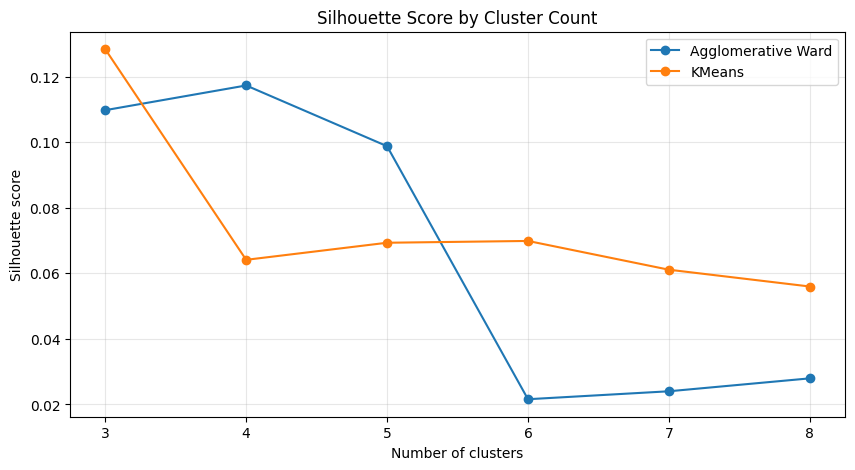

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for model_name, part in cluster_model_selection.groupby("model"):
    ax.plot(part["k"], part["silhouette"], marker="o", label=model_name)

ax.set_title("Silhouette Score by Cluster Count")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Fit final Clustering Model 

In [ ]:
# Pure metric optimization is not enough. Choose k based on both metrics
# and business interpretability. Five clusters often work well for sales activation:
# Power, Core, Emerging, Selective, Occasional/At-Risk.

FINAL_MODEL = "Agglomerative Ward"
FINAL_K = 5

if FINAL_MODEL == "Agglomerative Ward":
    final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
    cluster_labels = final_model.fit_predict(X)
elif FINAL_MODEL == "KMeans":
    final_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20)
    cluster_labels = final_model.fit_predict(X)
else:
    raise ValueError("Unsupported FINAL_MODEL")

df_cohort_clustering = clustering_df.copy()
df_cohort_clustering["cluster"] = cluster_labels

cluster_sizes = (
    df_cohort_clustering["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"cluster": "cluster", "count": "customers"}))
cluster_sizes["customer_share"] = cluster_sizes["customers"] / cluster_sizes["customers"].sum()

display(cluster_sizes)

,cluster,customers,customer_share
0,0,1409,0.71
1,1,42,0.02
2,2,161,0.08
3,3,59,0.03
4,4,322,0.16


Cluster Profiling

In [22]:
profile_metrics = [
    "Sales",
    "Units",
    "distinct_products",
    "prd_grp_1_coverage_pct",
    "prd_grp_3_coverage_pct",
    "active_months",
    "lifetime_months",
    "months_since_last_purchase",
    "activity_ratio_lifetime",
    "avg_inactive_gap_months",
    "avg_monthly_revenue",
    "historical_ltv",
    "purchase_freq_per_year",
    "sf_total_events",
    "sf_active_months",
    "sf_activity_ratio_lifetime",
    "sf_months_since_last_event",
    "sales_without_recent_sf_activity",
    "sf_activity_without_recent_sales"]

profile_metrics = [c for c in profile_metrics if c in df_cohort_clustering.columns]

cluster_feature_summary = (
    df_cohort_clustering
    .groupby("cluster")[profile_metrics]
    .agg(["mean", "median"]))

cluster_feature_summary.columns = [
    f"{metric}_{stat}" for metric, stat in cluster_feature_summary.columns]
cluster_feature_summary = cluster_feature_summary.reset_index()

display(cluster_feature_summary)


,cluster,Sales_mean,Sales_median,Units_mean,Units_median,distinct_products_mean,distinct_products_median,prd_grp_1_coverage_pct_mean,prd_grp_1_coverage_pct_median,prd_grp_3_coverage_pct_mean,prd_grp_3_coverage_pct_median,active_months_mean,active_months_median,lifetime_months_mean,lifetime_months_median,months_since_last_purchase_mean,months_since_last_purchase_median,activity_ratio_lifetime_mean,activity_ratio_lifetime_median,avg_inactive_gap_months_mean,avg_inactive_gap_months_median,avg_monthly_revenue_mean,avg_monthly_revenue_median,historical_ltv_mean,historical_ltv_median,purchase_freq_per_year_mean,purchase_freq_per_year_median,sf_total_events_mean,sf_total_events_median,sf_active_months_mean,sf_active_months_median,sf_activity_ratio_lifetime_mean,sf_activity_ratio_lifetime_median,sales_without_recent_sf_activity_mean,sales_without_recent_sf_activity_median,sf_activity_without_recent_sales_mean,sf_activity_without_recent_sales_median
0,0,"27,293.89","15,334.38",99.18,60.00,7.35,7.00,0.65,0.67,0.19,0.17,9.87,9.00,26.00,28.00,4.61,2.00,0.40,0.37,2.59,1.89,"1,084.82",623.99,"27,293.89","15,334.38",4.79,4.46,54.48,53.00,18.39,18.00,0.54,0.53,0.00,0.00,0.23,0.00
1,1,"17,575.17","11,656.56",60.60,38.00,7.55,8.00,0.64,0.67,0.18,0.17,8.48,8.00,29.79,31.00,2.40,2.00,0.29,0.26,3.33,3.29,601.40,396.29,"17,575.17","11,656.56",3.46,3.13,27.36,26.00,8.83,8.00,0.37,0.34,0.95,1.00,0.00,0.00
2,2,"7,765.87","4,135.68",27.38,15.00,4.73,5.00,0.50,0.50,0.13,0.11,4.05,4.00,10.66,9.00,23.14,26.00,0.51,0.43,2.25,2.00,841.64,503.91,"7,765.87","4,135.68",6.13,5.14,52.86,54.00,21.42,23.00,0.61,0.64,0.00,0.00,0.96,1.00
3,3,"647,774.28","600,971.90","1,961.73","1,818.00",8.47,9.00,0.65,0.67,0.20,0.20,28.71,29.00,35.20,35.00,0.34,0.00,0.82,0.82,0.24,0.22,"18,380.75","17,809.34","647,774.28","600,971.90",9.79,9.88,108.59,109.00,25.76,26.00,0.73,0.74,0.00,0.00,0.00,0.00
4,4,"165,268.34","144,236.61",639.94,570.50,8.65,9.00,0.70,0.67,0.22,0.23,28.06,29.00,34.97,35.00,0.38,0.00,0.80,0.81,0.27,0.25,"4,711.43","4,047.17","165,268.34","144,236.61",9.61,9.67,102.32,102.00,25.18,25.00,0.72,0.72,0.00,0.00,0.00,0.00


In [ ]:
# compute overall avg of each metric
overall_means = df_cohort_clustering[profile_metrics].mean(numeric_only=True)

# compute avg within each cluster & convert into an index. > 1.0 -> above avg. < 1.0 -> below avg
cluster_means = df_cohort_clustering.groupby("cluster")[profile_metrics].mean(numeric_only=True)

cluster_index = cluster_means.divide(overall_means.replace(0, np.nan), axis=1)
cluster_index = cluster_index.replace([np.inf, -np.inf], np.nan).fillna(0)
cluster_index = cluster_index.reset_index()

display(cluster_index)

,cluster,Sales,Units,distinct_products,prd_grp_1_coverage_pct,prd_grp_3_coverage_pct,active_months,lifetime_months,months_since_last_purchase,activity_ratio_lifetime,avg_inactive_gap_months,avg_monthly_revenue,historical_ltv,purchase_freq_per_year,sf_total_events,sf_active_months,sf_activity_ratio_lifetime,sales_without_recent_sf_activity,sf_activity_without_recent_sales
0,0,0.41,0.42,0.99,1.01,1.00,0.77,0.98,0.88,0.83,1.21,0.50,0.41,0.83,0.86,0.93,0.94,0.00,0.96
1,1,0.27,0.26,1.02,0.99,0.99,0.66,1.12,0.46,0.60,1.56,0.28,0.27,0.60,0.43,0.45,0.64,47.45,0.00
2,2,0.12,0.12,0.64,0.77,0.68,0.31,0.40,4.41,1.06,1.05,0.39,0.12,1.06,0.84,1.08,1.06,0.00,3.96
3,3,9.79,8.35,1.15,1.00,1.08,2.23,1.33,0.06,1.69,0.11,8.54,9.79,1.69,1.72,1.30,1.28,0.00,0.00
4,4,2.50,2.72,1.17,1.08,1.15,2.18,1.32,0.07,1.66,0.13,2.19,2.50,1.66,1.62,1.28,1.25,0.00,0.00


Assign Business Cohort Names

In [47]:
# build a cluster profile table
profile_for_labeling = (
    df_cohort_clustering
    .groupby("cluster")
    .agg(
        customers=("ID_Customer", "count"),
        avg_sales=("Sales", "mean"),
        avg_activity_ratio=("activity_ratio_lifetime", "mean"),
        avg_months_since_last_purchase=("months_since_last_purchase", "mean"),
        avg_product_breadth=("distinct_products", "mean"),
        avg_sf_events=("sf_total_events", "mean"))
    .reset_index())

# cohort-wide reference points
sales_q85 = profile_for_labeling["avg_sales"].quantile(0.85)
sales_q50 = profile_for_labeling["avg_sales"].quantile(0.50)
activity_q75 = profile_for_labeling["avg_activity_ratio"].quantile(0.75)
activity_q50 = profile_for_labeling["avg_activity_ratio"].quantile(0.50)
recency_q25 = profile_for_labeling["avg_months_since_last_purchase"].quantile(0.25)
recency_q85 = profile_for_labeling["avg_months_since_last_purchase"].quantile(0.85)
breadth_q75 = profile_for_labeling["avg_product_breadth"].quantile(0.75)
breadth_q50 = profile_for_labeling["avg_product_breadth"].quantile(0.50)
sf_q75 = profile_for_labeling["avg_sf_events"].quantile(0.75)

# assign a label to each cluster
def cohort_name(row):
    high_value = row["avg_sales"] >= sales_q85
    mid_value = row["avg_sales"] >= sales_q50
    highly_active = row["avg_activity_ratio"] >= activity_q75
    moderately_active = row["avg_activity_ratio"] >= activity_q50
    very_recent = row["avg_months_since_last_purchase"] <= recency_q25
    very_lapsed = row["avg_months_since_last_purchase"] >= recency_q85
    broad_buyer = row["avg_product_breadth"] >= breadth_q75
    mid_buyer = row["avg_product_breadth"] >= breadth_q50
    high_touch = row["avg_sf_events"] >= sf_q75

    if high_value and highly_active and very_recent:
        return "Power"

    if highly_active and broad_buyer and very_recent:
        return "Core"

    if very_lapsed and not mid_value:
        return "Dormant"

    if mid_value and not very_lapsed:
        return "Emerging"

    if very_recent and not highly_active:
        return "New / Re-Activated"

    if moderately_active and broad_buyer:
        return "Core Growth"

    if high_touch and not high_value:
        return "High-Touch Developing "

    return "Occasional"

profile_for_labeling["cohort_ML"] = profile_for_labeling.apply(cohort_name, axis=1)

# keep names unique if two clusters land in the same behavioral bucket
duplicated_labels = profile_for_labeling["cohort_ML"].duplicated(keep=False)

profile_for_labeling.loc[duplicated_labels, "cohort_ML"] = (
    profile_for_labeling.loc[duplicated_labels, "cohort_ML"]
    + " - Cluster "
    + profile_for_labeling.loc[duplicated_labels, "cluster"].astype(str)
)

cluster_name_map = dict(zip(profile_for_labeling["cluster"], profile_for_labeling["cohort_ML"]))

df_cohort_clustering["cohort_ML"] = df_cohort_clustering["cluster"].map(cluster_name_map)

display(profile_for_labeling.sort_values("cluster"))
display(df_cohort_clustering[["ID_Customer", "cluster", "cohort_ML"]].head())

display(profile_for_labeling.sort_values("cluster"))
display(df_cohort_clustering[["ID_Customer", "cluster", "cohort_ML"]].head())

,cluster,customers,avg_sales,avg_activity_ratio,avg_months_since_last_purchase,avg_product_breadth,avg_sf_events,cohort_ML
0,0,1409,"27,293.89",0.40,4.61,7.35,54.48,Emerging
1,1,42,"17,575.17",0.29,2.40,7.55,27.36,Occasional
2,2,161,"7,765.87",0.51,23.14,4.73,52.86,Dormant
3,3,59,"647,774.28",0.82,0.34,8.47,108.59,Power
4,4,322,"165,268.34",0.80,0.38,8.65,102.32,Core


,ID_Customer,cluster,cohort_ML
0,C00001,0,Emerging
1,C00002,0,Emerging
2,C00003,4,Core
3,C00004,4,Core
4,C00005,0,Emerging


,cluster,customers,avg_sales,avg_activity_ratio,avg_months_since_last_purchase,avg_product_breadth,avg_sf_events,cohort_ML
0,0,1409,"27,293.89",0.40,4.61,7.35,54.48,Emerging
1,1,42,"17,575.17",0.29,2.40,7.55,27.36,Occasional
2,2,161,"7,765.87",0.51,23.14,4.73,52.86,Dormant
3,3,59,"647,774.28",0.82,0.34,8.47,108.59,Power
4,4,322,"165,268.34",0.80,0.38,8.65,102.32,Core


,ID_Customer,cluster,cohort_ML
0,C00001,0,Emerging
1,C00002,0,Emerging
2,C00003,4,Core
3,C00004,4,Core
4,C00005,0,Emerging


In [ ]:
""" cohort_reference_points_for_labeling = pd.DataFrame({
    "reference_point": [
        "sales_q85",
        "sales_q50",
        "activity_q75",
        "activity_q50",
        "recency_q25",
        "recency_q85",
        "breadth_q75",
        "mid_buyer",
        "sf_q75"
    ],
    "value": [
        sales_q85,
        sales_q50,
        activity_q75,
        activity_q50,
        recency_q25,
        recency_q85,
        breadth_q75,
        breadth_q50,
        sf_q75
    ]
})

display(cohort_reference_points_for_labeling) """

,reference_point,value
0,sales_q85,"358,270.72"
1,sales_q50,"27,293.89"
2,activity_q75,0.80
3,activity_q50,0.51
4,recency_q25,0.38
5,recency_q85,12.02
6,breadth_q75,8.47
7,mid_buyer,7.55
8,sf_q75,102.32


Business Cluster Profile 

In [48]:
cluster_profile = (
    df_cohort_clustering
    .groupby(["cluster", "cohort_ML"], as_index=False)
    .agg(
        customers=("ID_Customer", "count"),
        total_sales=("Sales", "sum"),
        avg_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        avg_active_months=("active_months", "mean"),
        avg_lifetime_months=("lifetime_months", "mean"),
        avg_months_since_last_purchase=("months_since_last_purchase", "mean"),
        avg_activity_ratio=("activity_ratio_lifetime", "mean"),
        avg_distinct_products=("distinct_products", "mean"),
        avg_prd_grp_1_coverage_pct=("prd_grp_1_coverage_pct", "mean"),
        avg_prd_grp_3_coverage_pct=("prd_grp_3_coverage_pct", "mean"),
        avg_sf_total_events=("sf_total_events", "mean"),
        sales_without_recent_sf_activity=("sales_without_recent_sf_activity", "sum"),
        sf_activity_without_recent_sales=("sf_activity_without_recent_sales", "sum"))
    .sort_values("total_sales", ascending=False))

cluster_profile["customer_share"] = cluster_profile["customers"] / cluster_profile["customers"].sum()
cluster_profile["sales_share"] = cluster_profile["total_sales"] / cluster_profile["total_sales"].sum()

display(cluster_profile)


,cluster,cohort_ML,customers,total_sales,avg_sales,median_sales,avg_active_months,avg_lifetime_months,avg_months_since_last_purchase,avg_activity_ratio,avg_distinct_products,avg_prd_grp_1_coverage_pct,avg_prd_grp_3_coverage_pct,avg_sf_total_events,sales_without_recent_sf_activity,sf_activity_without_recent_sales,customer_share,sales_share
4,4,Core,322,"53,216,406.49","165,268.34","144,236.61",28.06,34.97,0.38,0.80,8.65,0.70,0.22,102.32,0,0,0.16,0.40
0,0,Emerging,1409,"38,457,084.03","27,293.89","15,334.38",9.87,26.00,4.61,0.40,7.35,0.65,0.19,54.48,0,327,0.71,0.29
3,3,Power,59,"38,218,682.62","647,774.28","600,971.90",28.71,35.20,0.34,0.82,8.47,0.65,0.20,108.59,0,0,0.03,0.29
2,2,Dormant,161,"1,250,304.68","7,765.87","4,135.68",4.05,10.66,23.14,0.51,4.73,0.50,0.13,52.86,0,154,0.08,0.01
1,1,Occasional,42,"738,157.20","17,575.17","11,656.56",8.48,29.79,2.40,0.29,7.55,0.64,0.18,27.36,40,0,0.02,0.01


In [49]:
display(
    df_cohort_clustering
    .groupby(["cluster", "cohort_ML"])["sales_value_segment"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .sort_values(["cluster", "share"], ascending=[True, False]))

,cluster,cohort_ML,sales_value_segment,share
0,0,Emerging,Mid Value,0.32
1,0,Emerging,High Value,0.30
2,0,Emerging,Low Value,0.26
3,0,Emerging,Top Value,0.12
4,1,Occasional,Low Value,0.36
5,1,Occasional,Mid Value,0.36
6,1,Occasional,High Value,0.21
7,1,Occasional,Top Value,0.07
8,2,Dormant,Low Value,0.70
9,2,Dormant,Mid Value,0.20


PCA Visualization

Explained variance: [0.18651457 0.071164  ]


,ID_Customer,PC1,PC2,cluster,cohort_ML
0,C00001,4.75,1.05,0,Emerging
1,C00002,-1.90,-3.14,0,Emerging
2,C00003,7.75,-0.21,4,Core
3,C00004,4.58,0.89,4,Core
4,C00005,0.91,0.57,0,Emerging


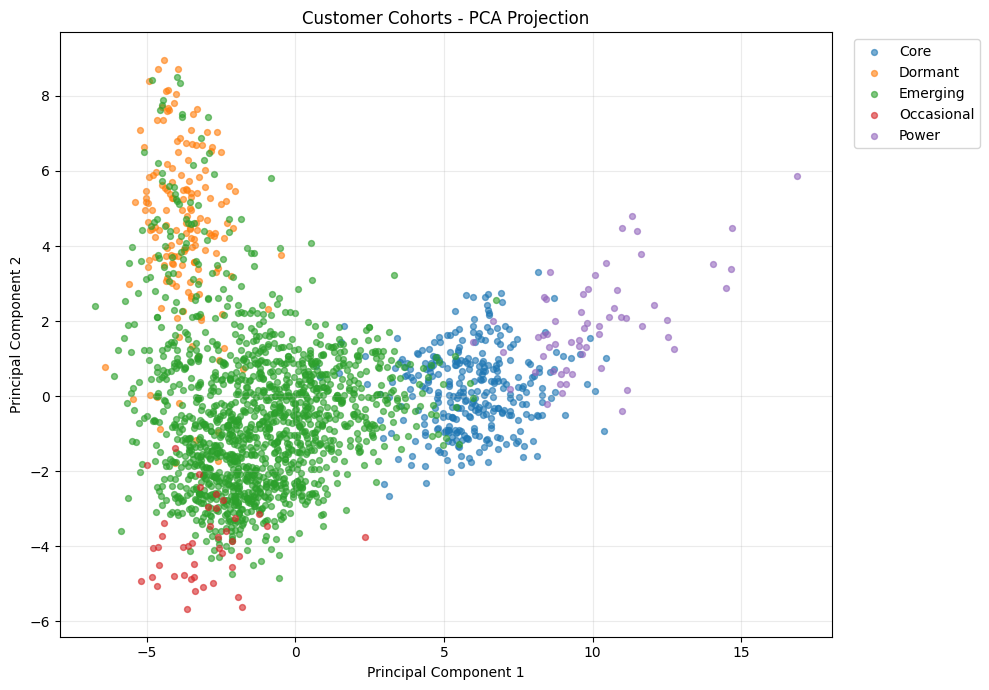

In [50]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X.toarray() if hasattr(X, "toarray") else X)

pca_df = pd.DataFrame({
    "ID_Customer": df_cohort_clustering["ID_Customer"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_cohort_clustering["cluster"],
    "cohort_ML": df_cohort_clustering["cohort_ML"]})

print("Explained variance:", pca.explained_variance_ratio_)
display(pca_df.head())

fig, ax = plt.subplots(figsize=(10, 7))
for cohort, part in pca_df.groupby("cohort_ML"):
    ax.scatter(part["PC1"], part["PC2"], s=18, alpha=0.60, label=cohort)

ax.set_title("Customer Cohorts - PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Sales Activation Recommendations by Cohort

In [52]:
activation_recommendations = pd.DataFrame([
    {
        "cohort_ML": "Power",
        "business_meaning": "High-value, active, broad-product customers.",
        "recommended_action": "Protect relationship, offer premium bundles, prioritize strategic account management."},
    {
        "cohort_ML": "Core",
        "business_meaning": "Consistent customers with good engagement and cross-sell potential.",
        "recommended_action": "Use product recommendations for systematic cross-sell and upsell campaigns."},
    {
        "cohort_ML": "Emerging",
        "business_meaning": "Recent or growing customers with lower current value but positive momentum.",
        "recommended_action": "Nurture with onboarding, starter bundles, and next-best-product offers."},
    {
        "cohort_ML": "Occasional",
        "business_meaning": "Customers with narrower buying patterns or specific needs.",
        "recommended_action": "Target with highly relevant product recommendations, avoid broad generic campaigns."},
    {
        "cohort_ML": "Dormant",
        "business_meaning": "Customers with inactivity, long purchase gaps, or weak recent buying behavior.",
        "recommended_action": "Trigger win-back or reactivation campaigns; prioritize only if value potential is high."}])

# also create rows for suffixed labels like 'Core Active Customers - Cluster 2'.
actual_labels = pd.Series(df_cohort_clustering["cohort_ML"].unique(), name="cohort_ML")
activation_recommendations_expanded = actual_labels.to_frame()
activation_recommendations_expanded["base_label"] = (
    activation_recommendations_expanded["cohort_ML"]
    .str.replace(r" - Cluster \d+$", "", regex=True))
activation_recommendations_expanded = activation_recommendations_expanded.merge(
    activation_recommendations.rename(columns={"cohort_ML": "base_label"}),
    on="base_label",
    how="left",
).drop(columns=["base_label"])

display(activation_recommendations_expanded)


,cohort_ML,business_meaning,recommended_action
0,Emerging,Recent or growing customers with lower current...,"Nurture with onboarding, starter bundles, and ..."
1,Core,Consistent customers with good engagement and ...,Use product recommendations for systematic cro...
2,Occasional,Customers with narrower buying patterns or spe...,Target with highly relevant product recommenda...
3,Dormant,"Customers with inactivity, long purchase gaps,...",Trigger win-back or reactivation campaigns; pr...
4,Power,"High-value, active, broad-product customers.","Protect relationship, offer premium bundles, p..."


Safe Outputs 

In [53]:
outputs = {
    "df_cohort_clustering": df_cohort_clustering,
    "df_clustering_output": df_cohort_clustering,
    "cluster_profile": cluster_profile,
    "cluster_feature_summary": cluster_feature_summary,
    "cluster_index": cluster_index,
    "cluster_model_selection": cluster_model_selection,
    "cluster_activation_recommendations": activation_recommendations_expanded,
    "pca_cluster_projection": pca_df}

for name, df in outputs.items():
    df.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print("Saved files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Saved files:
- cluster_activation_recommendations.csv
- cluster_feature_summary.csv
- cluster_index.csv
- cluster_model_selection.csv
- cluster_profile.csv
- df_clustering_output.csv
- df_cohort_clustering.csv
- pca_cluster_projection.csv
